In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from mgwr.sel_bw import Sel_BW
from mgwr.gwr import MGWR

In [2]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_raw = project_root / "data_raw"

mgwr_path = data_raw / "tokyo_mgwr_ready.geojson"
gdf_mgwr = gpd.read_file(mgwr_path)

print(gdf_mgwr.shape)
print(gdf_mgwr.crs)
gdf_mgwr.head()

(218, 10)
EPSG:6677


,N03_007,N03_001,N03_004,N03_005,foreign_ratio,log_dist_to_station_m,log_median_land_price_jpy,ols_resid,lisa_cluster,geometry
0,11101,埼玉県,さいたま市,西区,0.015422,7.105491,11.678448,-0.014858,Not significant,"MULTIPOLYGON (((-25741.989 -7274.146, -25724.9..."
1,11102,埼玉県,さいたま市,北区,0.018455,5.933088,12.061053,-0.017581,Low-Low,"POLYGON ((-19464.582 -3877.533, -19423.753 -38..."
2,11103,埼玉県,さいたま市,大宮区,0.027177,2.982405,12.553206,-0.020402,Low-Low,"POLYGON ((-17656.644 -8549.615, -17623.916 -85..."
3,11104,埼玉県,さいたま市,見沼区,0.021768,6.913789,11.608245,-0.008623,Low-Low,"POLYGON ((-14986.573 -3932.152, -14966.946 -39..."
4,11105,埼玉県,さいたま市,中央区,0.019989,4.556274,12.639480,-0.023614,Not significant,"POLYGON ((-19047.367 -10824.812, -19007.183 -1..."


In [3]:
print(gdf_mgwr.crs)

EPSG:6677


In [4]:
print(gdf_mgwr.crs)

EPSG:6677


In [5]:
gdf_mgwr["centroid"] = gdf_mgwr.geometry.centroid

gdf_mgwr[["N03_007", "centroid"]].head()

,N03_007,centroid
0,11101,POINT (-23317.549 -10030.157)
1,11102,POINT (-19689.121 -6733.246)
2,11103,POINT (-18907.834 -10357.563)
3,11104,POINT (-15073.645 -8078.831)
4,11105,POINT (-18832.133 -13146.806)


In [6]:
coords = np.array([
    (geom.x, geom.y) for geom in gdf_mgwr["centroid"]
])

print(coords.shape)
print(coords[:5])

(218, 2)
[[-23317.54858894 -10030.15711095]
 [-19689.12123295  -6733.24582243]
 [-18907.83362149 -10357.56319356]
 [-15073.64453894  -8078.83101566]
 [-18832.13349708 -13146.80599428]]


In [7]:
y = gdf_mgwr["foreign_ratio"].values.reshape((-1, 1))
print(y.shape)

(218, 1)


In [8]:
X = gdf_mgwr[[
    "log_dist_to_station_m",
    "log_median_land_price_jpy"
]].values
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X_scaled = (X - X_mean) / X_std

print(X_scaled.shape)
print(X_scaled[:5])
print(X.shape)

(218, 2)
[[ 0.2123005  -0.07038602]
 [-0.91585988  0.3082079 ]
 [-3.7551957   0.79520234]
 [ 0.02783315 -0.13985381]
 [-2.24071881  0.88057268]]
(218, 2)


In [9]:
print(coords.shape)
print(y.shape)
print(X_scaled.shape)

print("coords has NaN:", np.isnan(coords).sum())
print("y has NaN:", np.isnan(y).sum())
print("X_scaled has NaN:", np.isnan(X_scaled).sum())

(218, 2)
(218, 1)
(218, 2)
coords has NaN: 0
y has NaN: 0
X_scaled has NaN: 0


In [10]:
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import MGWR

In [11]:
selector = Sel_BW(coords, y, X_scaled, multi=True)
bw = selector.search()

print("Selected bandwidths:", bw)

Selected bandwidths: [44. 52. 44.]


In [12]:
mgwr_model = MGWR(coords, y, X_scaled, selector, fixed=False, kernel='bisquare')
mgwr_results = mgwr_model.fit()

print(mgwr_results.summary())

Model type                                                         Gaussian
Number of observations:                                                 218
Number of covariates:                                                     3

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                              0.076
Log-likelihood:                                                     558.410
AIC:                                                              -1110.821
AICc:                                                             -1108.633
BIC:                                                              -1157.590
R2:                                                                   0.164
Adj. R2:                                                              0.156

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [13]:
print(mgwr_results.params.shape)

(218, 3)


In [14]:
gdf_mgwr["mgwr_intercept"] = mgwr_results.params[:, 0]
gdf_mgwr["mgwr_beta_logdist"] = mgwr_results.params[:, 1]
gdf_mgwr["mgwr_beta_logland"] = mgwr_results.params[:, 2]

gdf_mgwr[[
    "N03_007",
    "mgwr_intercept",
    "mgwr_beta_logdist",
    "mgwr_beta_logland"
]].head()

,N03_007,mgwr_intercept,mgwr_beta_logdist,mgwr_beta_logland
0,11101,0.023666,0.001110,0.004924
1,11102,0.022683,0.000859,0.005335
2,11103,0.025168,0.000640,0.007991
3,11104,0.024548,0.000111,0.007881
4,11105,0.026856,-0.000410,0.008893


In [15]:
gdf_mgwr[[
    "mgwr_beta_logdist",
    "mgwr_beta_logland"
]].describe()

,mgwr_beta_logdist,mgwr_beta_logland
count,218.000000,218.000000
mean,-0.001997,0.003227
std,0.005199,0.007282
min,-0.014141,-0.017681
25%,-0.004672,0.000262
50%,-0.000683,0.003804
75%,0.001073,0.007902
max,0.008512,0.018191


In [16]:
print("logdist positive:", (gdf_mgwr["mgwr_beta_logdist"] > 0).sum())
print("logdist negative:", (gdf_mgwr["mgwr_beta_logdist"] < 0).sum())

print("logland positive:", (gdf_mgwr["mgwr_beta_logland"] > 0).sum())
print("logland negative:", (gdf_mgwr["mgwr_beta_logland"] < 0).sum())

logdist positive: 88
logdist negative: 130
logland positive: 167
logland negative: 51


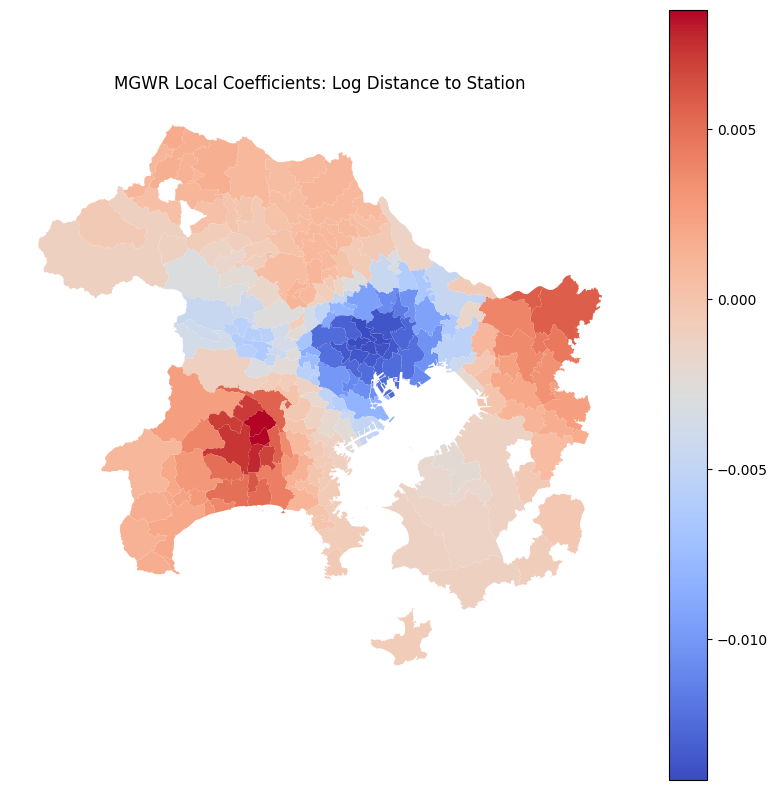

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_mgwr.plot(
    column="mgwr_beta_logdist",
    cmap="coolwarm",
    legend=True,
    ax=ax
)

ax.set_title("MGWR Local Coefficients: Log Distance to Station")
ax.set_axis_off()

plt.savefig("../outputs/figures/mgwr_logdist_map.png", dpi=300, bbox_inches="tight")
plt.show()

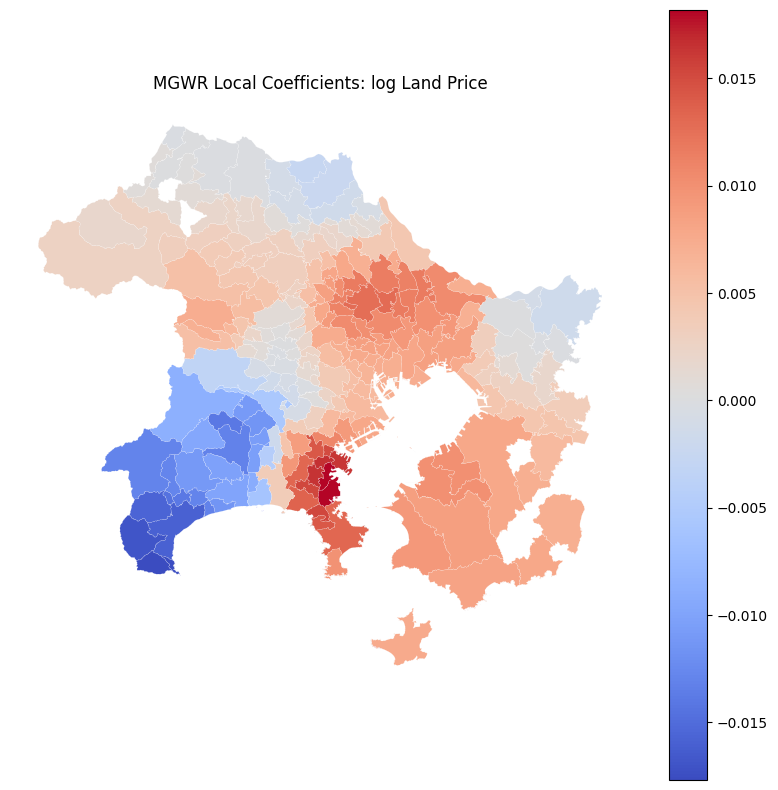

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_mgwr.plot(
    column="mgwr_beta_logland",
    cmap="coolwarm",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title("MGWR Local Coefficients: log Land Price")
ax.set_axis_off()
plt.show()

In [19]:
print(mgwr_results.params.shape)

(218, 3)


In [20]:
gdf_mgwr[[
    "mgwr_beta_logdist",
    "mgwr_beta_logland"
]].describe()

,mgwr_beta_logdist,mgwr_beta_logland
count,218.000000,218.000000
mean,-0.001997,0.003227
std,0.005199,0.007282
min,-0.014141,-0.017681
25%,-0.004672,0.000262
50%,-0.000683,0.003804
75%,0.001073,0.007902
max,0.008512,0.018191


## MGWR interpretation

The MGWR results provide strong evidence that the effects of station accessibility and residential land price on foreign population ratio vary substantially across the Tokyo metropolitan mainland area.

For log distance to station, the local coefficients range from negative to positive values. This indicates that railway accessibility is an important factor in some parts of the metropolitan area, especially in the Tokyo core and eastern urban belt, where greater station distance is associated with lower foreign population concentration. However, in parts of the southwestern and Kanagawa-side belt, this relationship weakens or even reverses, suggesting that foreign population distribution there is shaped by additional local mechanisms beyond simple rail accessibility.

For log median land price, the local coefficients are positive on average, but also vary considerably in space and become negative in some municipalities. The strongest positive effects appear in the central and bay-side urban core, where foreign population concentration is closely tied to high-value urban space. By contrast, negative effects appear in parts of the southwestern outer belt, implying that in those areas higher land price does not support foreign population agglomeration and may instead constrain it.

Overall, the MGWR results show that the Tokyo metropolitan mainland area does not follow a single foreign-population agglomeration mechanism. Instead, the relationships between accessibility, land value, and foreign population concentration are spatially differentiated, with distinct urban-core and outer-belt patterns.

In [21]:
print("logdist positive:", (gdf_mgwr["mgwr_beta_logdist"] > 0).sum())
print("logdist negative:", (gdf_mgwr["mgwr_beta_logdist"] < 0).sum())

print("logland positive:", (gdf_mgwr["mgwr_beta_logland"] > 0).sum())
print("logland negative:", (gdf_mgwr["mgwr_beta_logland"] < 0).sum())

logdist positive: 88
logdist negative: 130
logland positive: 167
logland negative: 51


In [22]:
gdf_mgwr[
    gdf_mgwr["N03_004"].astype(str).str.contains("川口|江戸川", na=False) |
    gdf_mgwr["N03_005"].astype(str).str.contains("川口|江戸川", na=False)
][[
    "N03_001", "N03_004", "N03_005", "N03_007",
    "foreign_ratio",
    "mgwr_beta_logdist",
    "mgwr_beta_logland"
]]

,N03_001,N03_004,N03_005,N03_007,foreign_ratio,mgwr_beta_logdist,mgwr_beta_logland
12,埼玉県,川口市,,11203,0.071131,-0.009522,0.012629
131,東京都,江戸川区,,13123,0.062204,-0.012213,0.007980
